In [ ]:
# Connect Colab to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set your project path
PROJECT = '/content/drive/MyDrive/nike_india_project'

print("✅ Drive mounted!")
print(f"📁 Project path: {PROJECT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
📁 Project path: /content/drive/MyDrive/nike_india_project


In [ ]:
import os

data_path = f'{PROJECT}/data'

# Create the directory if it doesn't exist
if not os.path.exists(data_path):
    os.makedirs(data_path)
    print(f"📂 Created directory: {data_path}")

files = os.listdir(data_path)

print("📂 Files in your data folder:")
if files:
    for f in files:
        print(f"   ✅ {f}")
else:
    print("   (No files found in the data folder)")

📂 Files in your data folder:
   ✅ nike_products.csv
   ✅ nike_sales.csv
   ✅ nike_reviews.csv


In [ ]:
# These are not pre-installed in Colab — install them first
!pip install wordcloud shap xgboost -q

print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import warnings
import os

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('punkt',        quiet=True)

os.makedirs(f'{PROJECT}/outputs/charts',     exist_ok=True)
os.makedirs(f'{PROJECT}/outputs/wordclouds', exist_ok=True)

plt.style.use('dark_background')

print("✅ All imports done!")

✅ All imports done!


In [ ]:
df_reviews  = pd.read_csv(f'{PROJECT}/data/nike_reviews.csv')
df_products = pd.read_csv(f'{PROJECT}/data/nike_products.csv')
df_sales    = pd.read_csv(f'{PROJECT}/data/nike_sales.csv')

print("✅ Loaded!")
print(f"   Reviews  → {df_reviews.shape[0]:,} rows")
print(f"   Products → {df_products.shape[0]:,} rows")
print(f"   Sales    → {df_sales.shape[0]:,} rows")

✅ Loaded!
   Reviews  → 4,587 rows
   Products → 112 rows
   Sales    → 9,360 rows


In [ ]:
print("=" * 55)
print("📋 REVIEWS — Columns & First 3 Rows")
print("=" * 55)
print("Columns:", df_reviews.columns.tolist())
print()
print(df_reviews.head(3))

print("\n" + "=" * 55)
print("📋 PRODUCTS — Columns & First 3 Rows")
print("=" * 55)
print("Columns:", df_products.columns.tolist())
print()
print(df_products.head(3))

print("\n" + "=" * 55)
print("📋 SALES — Columns & First 3 Rows")
print("=" * 55)
print("Columns:", df_sales.columns.tolist())
print()
print(df_sales.head(3))

📋 REVIEWS — Columns & First 3 Rows
Columns: ['Unnamed: 0', 'Rating', 'Review Date', 'Location', 'Username', 'Review', 'Fit Feedback', 'Comfort Feedback', 'Recommend Feedback', 'title', 'IsPromoReview', 'subtitle', 'colorDescription', 'fullPrice', 'discounted', 'employeePrice', 'currentPrice', 'isLaunch', 'pid', 'label']

   Unnamed: 0  Rating  Review Date Location       Username  \
0           0     5.0  Sep 8, 2023       US  Manny214Fresh   
1           1     5.0  Sep 8, 2023       US  Manny214Fresh   
2           2     5.0  Sep 8, 2023       US  Manny214Fresh   

                                              Review  Fit Feedback  \
0  Jordan Low 1 The delivery was on time as sched...  True to Size   
1  Jordan Low 1 The delivery was on time as sched...  True to Size   
2  Jordan Low 1 The delivery was on time as sched...  True to Size   

   Comfort Feedback Recommend Feedback             title  IsPromoReview  \
0  Very Comfortable                Yes  Air Jordan 1 Low          False 

In [ ]:
#Clean Reviews Dataset

# ── Rename columns to simple names ─────────────────────
df_reviews.rename(columns={
    'Rating'            : 'rating',
    'Review'            : 'review_text',
    'Review Date'       : 'review_date',
    'Location'          : 'location',
    'Username'          : 'username',
    'Fit Feedback'      : 'fit_feedback',
    'Comfort Feedback'  : 'comfort_feedback',
    'Recommend Feedback': 'recommend_feedback',
    'title'             : 'product_name',
    'currentPrice'      : 'current_price',
    'fullPrice'         : 'full_price',
    'discounted'        : 'is_discounted',
    'colorDescription'  : 'color',
    'IsPromoReview'     : 'is_promo',
    'label'             : 'stock_label'
}, inplace=True)

# ── Drop unwanted columns ──────────────────────────────
df_reviews.drop(columns=['Unnamed: 0', 'subtitle',
                          'employeePrice', 'isLaunch',
                          'pid'], inplace=True, errors='ignore')

print(f"Before cleaning: {len(df_reviews)} rows")

# ── Drop rows with no review text or rating ────────────
df_reviews.dropna(subset=['review_text', 'rating'], inplace=True)

# ── Fix rating to number ───────────────────────────────
df_reviews['rating'] = pd.to_numeric(df_reviews['rating'], errors='coerce')
df_reviews = df_reviews[df_reviews['rating'].between(1, 5)]

# ── Fix price to number ────────────────────────────────
df_reviews['current_price'] = pd.to_numeric(df_reviews['current_price'], errors='coerce')
df_reviews['full_price']    = pd.to_numeric(df_reviews['full_price'],    errors='coerce')

# ── Clean review text ──────────────────────────────────
df_reviews['review_text'] = (
    df_reviews['review_text']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
)

# ── Remove very short reviews ──────────────────────────
df_reviews['word_count'] = df_reviews['review_text'].str.split().str.len()
df_reviews = df_reviews[df_reviews['word_count'] >= 4]

# ── Remove duplicates ──────────────────────────────────
df_reviews.drop_duplicates(subset=['review_text'], inplace=True)

# ── Add sentiment label from rating ───────────────────
def label_rating(r):
    if r >= 4:   return 'Positive'
    elif r == 3: return 'Neutral'
    else:        return 'Negative'

df_reviews['sentiment_label'] = df_reviews['rating'].apply(label_rating)

# ── Add discount amount column ─────────────────────────
df_reviews['discount_amount'] = df_reviews['full_price'] - df_reviews['current_price']

# ── Reset index ────────────────────────────────────────
df_reviews.reset_index(drop=True, inplace=True)

print(f"After cleaning : {len(df_reviews)} rows")
print(f"\nSentiment breakdown:")
print(df_reviews['sentiment_label'].value_counts())
print(f"\nLocations in data:")
print(df_reviews['location'].value_counts().head(10))

Before cleaning: 4587 rows
After cleaning : 200 rows

Sentiment breakdown:
sentiment_label
Positive    191
Negative      5
Neutral       4
Name: count, dtype: int64

Locations in data:
location
US                   69
CA, US                4
Milwaukee, WI, US     2
London, GB            2
Baltimore, MD         2
Stamford, GB          1
Mobile, AL            1
Houston               1
New Mexico            1
Porter, TX            1
Name: count, dtype: int64


In [ ]:
 #Clean Products Dataset

# ── Rename columns ─────────────────────────────────────
df_products.rename(columns={
    'name'        : 'product_name',
    'price'       : 'price',
    'avg_rating'  : 'avg_rating',
    'review_count': 'review_count',
    'description' : 'description',
    'availability': 'availability',
    'color'       : 'color'
}, inplace=True)

# ── Fix types ──────────────────────────────────────────
df_products['price']        = pd.to_numeric(df_products['price'],        errors='coerce')
df_products['avg_rating']   = pd.to_numeric(df_products['avg_rating'],   errors='coerce')
df_products['review_count'] = pd.to_numeric(df_products['review_count'], errors='coerce')

# ── Drop rows with no product name ─────────────────────
df_products.dropna(subset=['product_name'], inplace=True)

# ── Keep only Nike brand ───────────────────────────────
if 'brand' in df_products.columns:
    df_products = df_products[df_products['brand'].str.lower() == 'nike']

# ── Reset index ────────────────────────────────────────
df_products.reset_index(drop=True, inplace=True)

print(f"✅ Clean products: {len(df_products)} rows")
print(df_products[['product_name','price','avg_rating','review_count']].head(5))

✅ Clean products: 112 rows
                              product_name   price  avg_rating  review_count
0  Nike Dri-FIT Team (MLB Minnesota Twins)   40.00         NaN           NaN
1                             Club América   90.00         5.0           1.0
2                   Nike Sportswear Swoosh  140.00         4.9          11.0
3                    Nike Dri-FIT One Luxe   22.97         NaN           NaN
4    Paris Saint-Germain Repel Academy AWF   70.00         NaN           NaN


In [ ]:
#  Clean Sales Dataset

# ── Rename columns ─────────────────────────────────────
df_sales.rename(columns={
    'Invoice Date'  : 'invoice_date',
    'Product'       : 'product',
    'Region'        : 'region',
    'Retailer'      : 'retailer',
    'Sales Method'  : 'sales_method',
    'State'         : 'state',
    'Price per Unit': 'price_per_unit',
    'Total Sales'   : 'total_sales',
    'Units Sold'    : 'units_sold'
}, inplace=True)

# ── Fix types ──────────────────────────────────────────
df_sales['invoice_date']  = pd.to_datetime(df_sales['invoice_date'], errors='coerce')
df_sales['total_sales']   = pd.to_numeric(df_sales['total_sales'],   errors='coerce')
df_sales['units_sold']    = pd.to_numeric(df_sales['units_sold'],    errors='coerce')
df_sales['price_per_unit']= pd.to_numeric(df_sales['price_per_unit'],errors='coerce')

df_sales.dropna(subset=['product','total_sales'], inplace=True)
df_sales.reset_index(drop=True, inplace=True)

print(f"✅ Clean sales: {len(df_sales)} rows")
print(df_sales.head(3))

✅ Clean sales: 9360 rows
  invoice_date                  product     region     retailer sales_method  \
0   2020-01-01    Men's Street Footwear  Northeast  Foot Locker     In-store   
1   2020-02-01  Men's Athletic Footwear  Northeast  Foot Locker     In-store   
2   2020-03-01  Women's Street Footwear  Northeast  Foot Locker     In-store   

      state  price_per_unit  total_sales  units_sold  
0  New York              50         6000         120  
1  New York              50         5000         100  
2  New York              40         4000         100  


In [ ]:
df_reviews.to_csv(f'{PROJECT}/outputs/clean_reviews.csv',  index=False)
df_products.to_csv(f'{PROJECT}/outputs/clean_products.csv', index=False)
df_sales.to_csv(f'{PROJECT}/outputs/clean_sales.csv',       index=False)

print("✅ All 3 clean files saved to Drive!")
print(f"   📄 clean_reviews.csv")
print(f"   📄 clean_products.csv")
print(f"   📄 clean_sales.csv")

✅ All 3 clean files saved to Drive!
   📄 clean_reviews.csv
   📄 clean_products.csv
   📄 clean_sales.csv


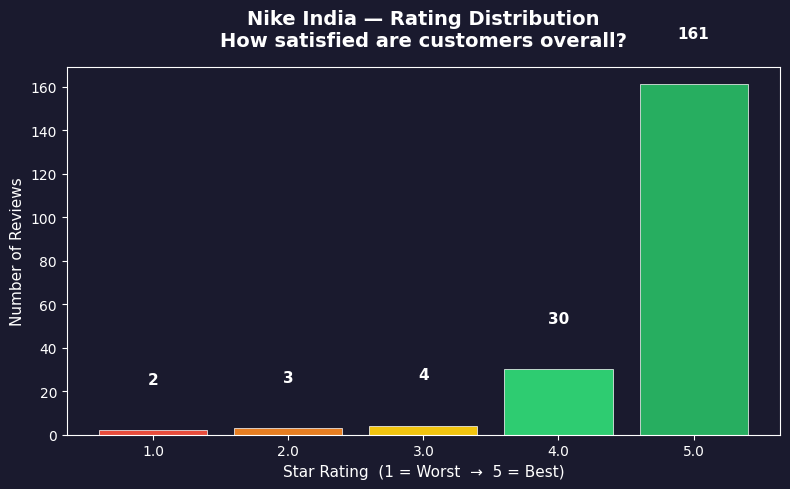

✅ Chart 1 saved!


In [ ]:
# Rating Distribution

fig, ax = plt.subplots(figsize=(8, 5))

rating_counts = df_reviews['rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

bars = ax.bar(rating_counts.index.astype(str),
              rating_counts.values,
              color=colors, edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')

ax.set_title('Nike India — Rating Distribution\nHow satisfied are customers overall?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating  (1 = Worst  →  5 = Best)', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

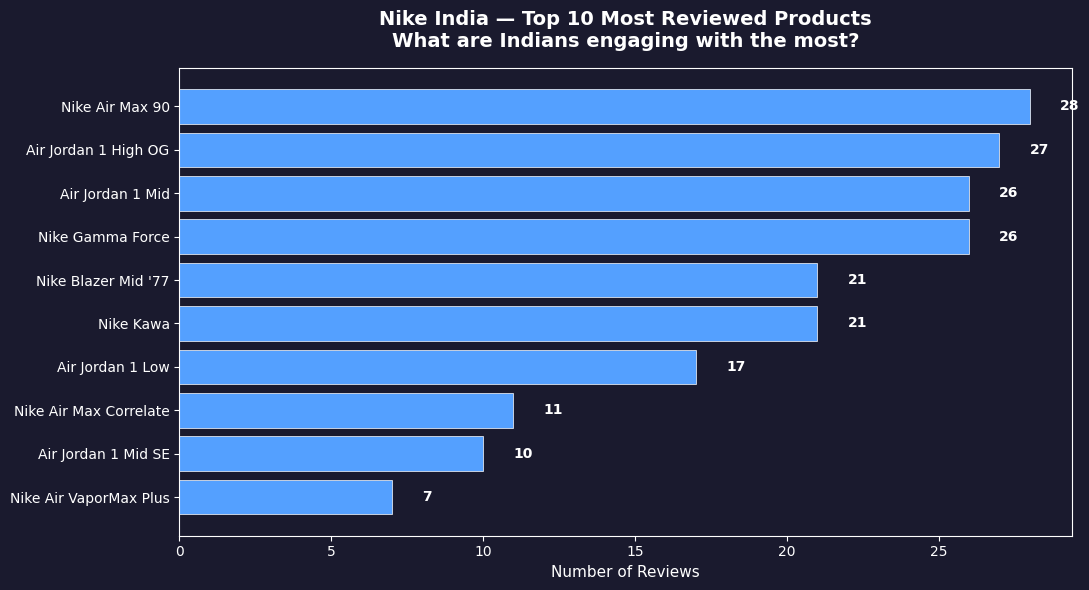

✅ Chart 2 saved!


In [ ]:
# Top 10 Most Reviewed Products

fig, ax = plt.subplots(figsize=(11, 6))

top10 = (df_reviews.groupby('product_name')
         .size().sort_values(ascending=False).head(10))

bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color='#54a0ff', edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_title('Nike India — Top 10 Most Reviewed Products\nWhat are Indians engaging with the most?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/02_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

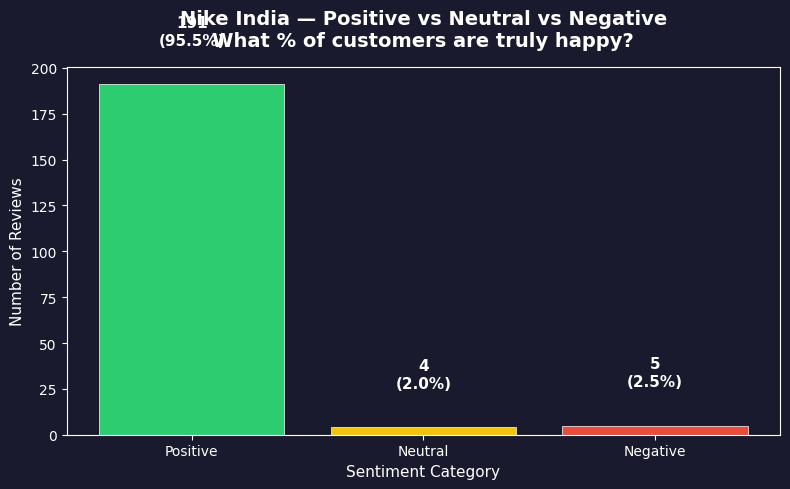

✅ Chart 3 saved!


In [ ]:
# Positive vs Negative Split

fig, ax = plt.subplots(figsize=(8, 5))

sent_counts = df_reviews['sentiment_label'].value_counts()
order       = ['Positive','Neutral','Negative']
sent_counts = sent_counts.reindex(order).fillna(0)
colors_sent = ['#2ecc71','#f1c40f','#e74c3c']

bars = ax.bar(sent_counts.index, sent_counts.values,
              color=colors_sent, edgecolor='white', linewidth=0.5)

total = sent_counts.sum()
for bar, val in zip(bars, sent_counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{int(val)}\n({pct:.1f}%)',
            ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')

ax.set_title('Nike India — Positive vs Neutral vs Negative\nWhat % of customers are truly happy?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment Category', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/03_sentiment_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

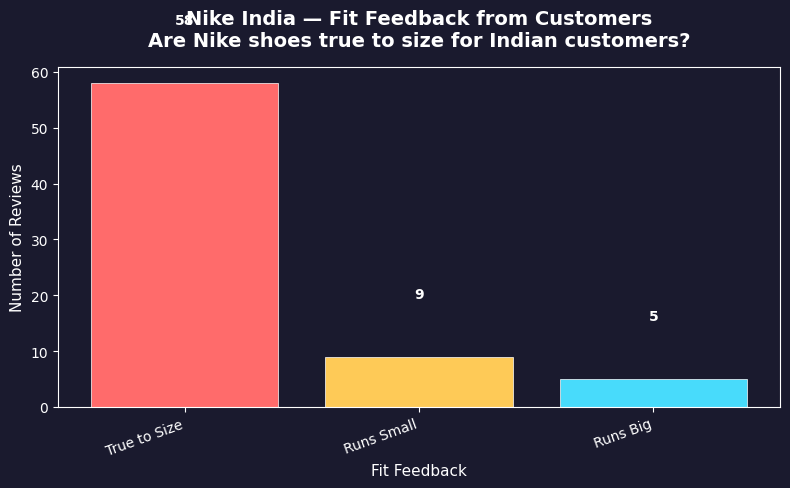

✅ Chart 4 saved!


In [ ]:
# Fit Feedback Distribution

# This uses your unique 'fit_feedback' column — most datasets don't have this!
fig, ax = plt.subplots(figsize=(8, 5))

fit_counts = df_reviews['fit_feedback'].value_counts()

bars = ax.bar(fit_counts.index, fit_counts.values,
              color=['#ff6b6b','#feca57','#48dbfb','#ff9ff3','#54a0ff'],
              edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

ax.set_title('Nike India — Fit Feedback from Customers\nAre Nike shoes true to size for Indian customers?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fit Feedback', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_xticklabels(fit_counts.index, rotation=20, ha='right')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/04_fit_feedback.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

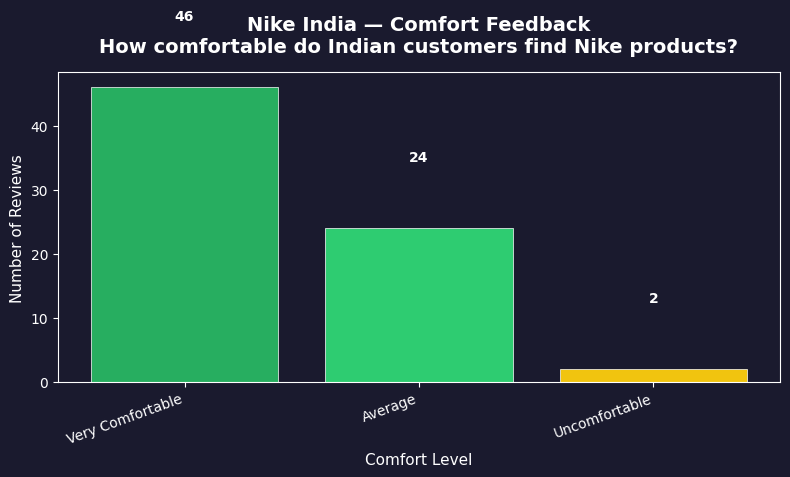

✅ Chart 5 saved!


In [ ]:
# Comfort Feedback Distribution

fig, ax = plt.subplots(figsize=(8, 5))

comfort_counts = df_reviews['comfort_feedback'].value_counts()

bars = ax.bar(comfort_counts.index, comfort_counts.values,
              color=['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c'],
              edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

ax.set_title('Nike India — Comfort Feedback\nHow comfortable do Indian customers find Nike products?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Comfort Level', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_xticklabels(comfort_counts.index, rotation=20, ha='right')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/05_comfort_feedback.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

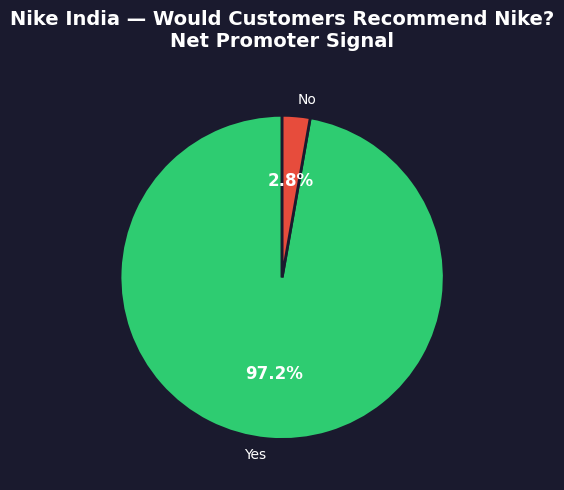

✅ Chart 6 saved!


In [ ]:
# Recommend Feedback

fig, ax = plt.subplots(figsize=(6, 5))

rec_counts = df_reviews['recommend_feedback'].value_counts()

wedges, texts, autotexts = ax.pie(
    rec_counts.values,
    labels=rec_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c','#f1c40f'],
    startangle=90,
    wedgeprops=dict(edgecolor='#1a1a2e', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
    t.set_color('white')

ax.set_title('Nike India — Would Customers Recommend Nike?\nNet Promoter Signal',
             fontsize=14, fontweight='bold', pad=20)
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/06_recommend_feedback.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

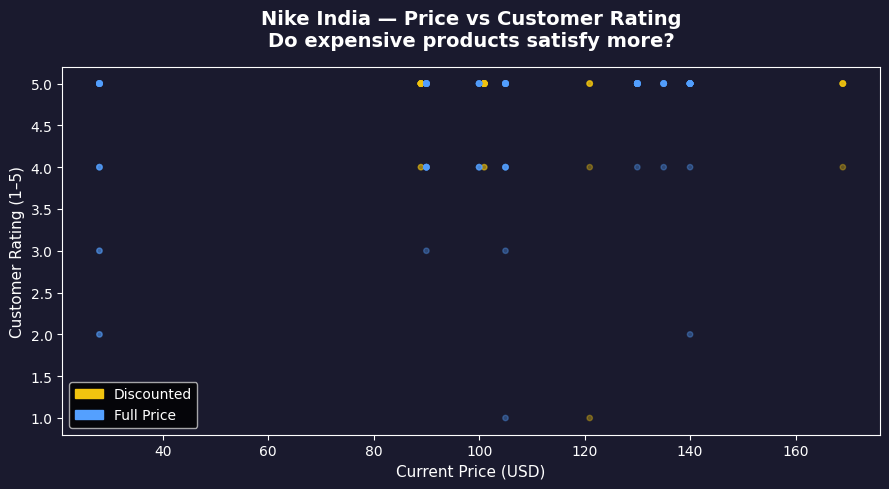

✅ Chart 7 saved!


In [ ]:
# Price vs Rating Scatter

fig, ax = plt.subplots(figsize=(9, 5))

# Filter out zero prices
df_price = df_reviews[df_reviews['current_price'] > 0].copy()

# Color by discount status
colors_disc = df_price['is_discounted'].map(
    {True: '#f1c40f', False: '#54a0ff',
     'True': '#f1c40f', 'False': '#54a0ff'}
).fillna('#54a0ff')

ax.scatter(df_price['current_price'],
           df_price['rating'],
           c=colors_disc, alpha=0.35, s=15)

ax.set_title('Nike India — Price vs Customer Rating\nDo expensive products satisfy more?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Current Price (USD)', fontsize=11)
ax.set_ylabel('Customer Rating (1–5)', fontsize=11)

yellow_patch = mpatches.Patch(color='#f1c40f', label='Discounted')
blue_patch   = mpatches.Patch(color='#54a0ff', label='Full Price')
ax.legend(handles=[yellow_patch, blue_patch], fontsize=10)

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/07_price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

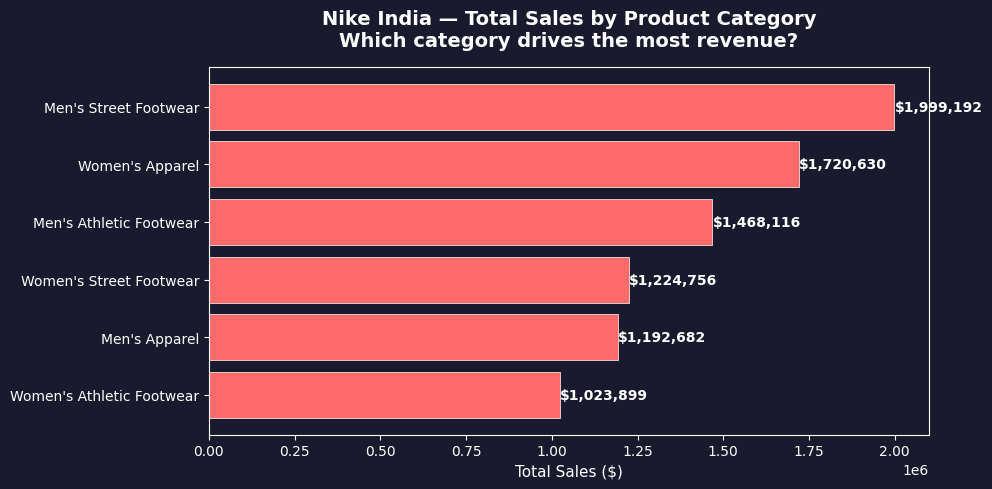

✅ Chart 8 saved!


In [ ]:
#  Sales by Product Category

fig, ax = plt.subplots(figsize=(10, 5))

sales_by_product = (df_sales.groupby('product')['total_sales']
                    .sum().sort_values(ascending=True))

bars = ax.barh(sales_by_product.index,
               sales_by_product.values,
               color='#ff6b6b', edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'${int(bar.get_width()):,}',
            va='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_title('Nike India — Total Sales by Product Category\nWhich category drives the most revenue?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/08_sales_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

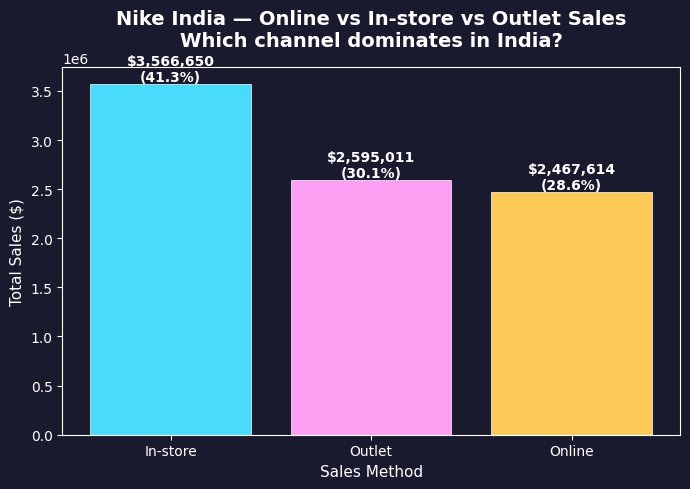

✅ Chart 9 saved!


In [ ]:
# Sales by Sales Method (Online vs In-store)

fig, ax = plt.subplots(figsize=(7, 5))

method_sales = (df_sales.groupby('sales_method')['total_sales']
                .sum().sort_values(ascending=False))

bars = ax.bar(method_sales.index, method_sales.values,
              color=['#48dbfb','#ff9ff3','#feca57'],
              edgecolor='white', linewidth=0.5)

total_s = method_sales.sum()
for bar, val in zip(bars, method_sales.values):
    pct = val / total_s * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${int(val):,}\n({pct:.1f}%)',
            ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

ax.set_title('Nike India — Online vs In-store vs Outlet Sales\nWhich channel dominates in India?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sales Method', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/09_sales_by_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

In [ ]:
# Confirm All Charts Saved

saved = sorted(os.listdir(f'{PROJECT}/outputs/charts'))
print(f"✅ {len(saved)} charts saved:\n")
for c in saved:
    print(f"   📊 {c}")

✅ 9 charts saved:

   📊 01_rating_distribution.png
   📊 02_top10_products.png
   📊 03_sentiment_split.png
   📊 04_fit_feedback.png
   📊 05_comfort_feedback.png
   📊 06_recommend_feedback.png
   📊 07_price_vs_rating.png
   📊 08_sales_by_product.png
   📊 09_sales_by_method.png


In [ ]:
# Run VADER on Every Review

# ── Create the VADER analyser ──────────────────────────
sid = SentimentIntensityAnalyzer()

# ── Score every review ─────────────────────────────────
# compound = overall score from -1 to +1
# pos      = how much positive language
# neg      = how much negative language
# neu      = how much neutral language

df_reviews['vader_compound'] = df_reviews['review_text'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)
df_reviews['vader_pos'] = df_reviews['review_text'].apply(
    lambda x: sid.polarity_scores(str(x))['pos']
)
df_reviews['vader_neg'] = df_reviews['review_text'].apply(
    lambda x: sid.polarity_scores(str(x))['neg']
)
df_reviews['vader_neu'] = df_reviews['review_text'].apply(
    lambda x: sid.polarity_scores(str(x))['neu']
)

# ── Convert score to a simple label ───────────────────
# compound >= 0.05  → Positive
# compound <= -0.05 → Negative
# in between        → Neutral

def vader_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_reviews['vader_label'] = df_reviews['vader_compound'].apply(vader_label)

print("✅ VADER scoring done!")
print(f"\nTotal reviews scored: {len(df_reviews):,}")
print(f"\nVADER Label breakdown:")
print(df_reviews['vader_label'].value_counts())
print(f"\nAverage VADER compound score: {df_reviews['vader_compound'].mean():.3f}")
print(f"\nSample — first 5 reviews with scores:")
print(df_reviews[['review_text','rating','vader_compound','vader_label']].head())

✅ VADER scoring done!

Total reviews scored: 200

VADER Label breakdown:
vader_label
Positive    194
Negative      4
Neutral       2
Name: count, dtype: int64

Average VADER compound score: 0.797

Sample — first 5 reviews with scores:
                                         review_text  rating  vader_compound  \
0  jordan low 1 the delivery was on time as sched...     5.0          0.8934   
1  runs big beautiful shoes but runs big i m usua...     4.0          0.7184   
2           i love the shoes i definitely recommend      5.0          0.8555   
3  love my low dunks my 1st pair of low dunks and...     5.0          0.8481   
4  jordan low shoes these shoes met all of our ex...     5.0          0.5267   

  vader_label  
0    Positive  
1    Positive  
2    Positive  
3    Positive  
4    Positive  


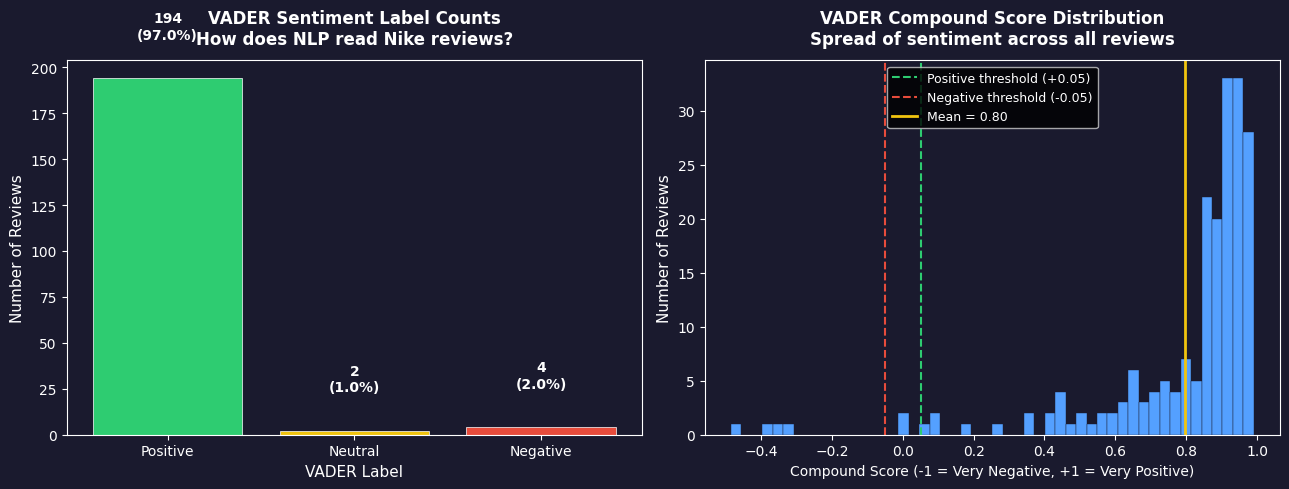

✅ Chart 10 saved!


In [ ]:
# VADER Sentiment Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left chart: VADER label counts ────────────────────
vader_counts = df_reviews['vader_label'].value_counts()
order = ['Positive', 'Neutral', 'Negative']
vader_counts = vader_counts.reindex(order).fillna(0)
colors_v = ['#2ecc71', '#f1c40f', '#e74c3c']

bars = axes[0].bar(vader_counts.index, vader_counts.values,
                   color=colors_v, edgecolor='white', linewidth=0.5)

total = vader_counts.sum()
for bar, val in zip(bars, vader_counts.values):
    pct = val / total * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{int(val)}\n({pct:.1f}%)',
                 ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

axes[0].set_title('VADER Sentiment Label Counts\nHow does NLP read Nike reviews?',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('VADER Label', fontsize=11)
axes[0].set_ylabel('Number of Reviews', fontsize=11)
axes[0].set_facecolor('#1a1a2e')

# ── Right chart: VADER compound score histogram ────────
axes[1].hist(df_reviews['vader_compound'], bins=50,
             color='#54a0ff', edgecolor='#1a1a2e', linewidth=0.3)

axes[1].axvline(x=0.05,  color='#2ecc71', linestyle='--',
                linewidth=1.5, label='Positive threshold (+0.05)')
axes[1].axvline(x=-0.05, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Negative threshold (-0.05)')
axes[1].axvline(x=df_reviews['vader_compound'].mean(),
                color='#f1c40f', linestyle='-',
                linewidth=2, label=f"Mean = {df_reviews['vader_compound'].mean():.2f}")

axes[1].set_title('VADER Compound Score Distribution\nSpread of sentiment across all reviews',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Compound Score (-1 = Very Negative, +1 = Very Positive)', fontsize=10)
axes[1].set_ylabel('Number of Reviews', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#1a1a2e')

fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/10_vader_sentiment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")

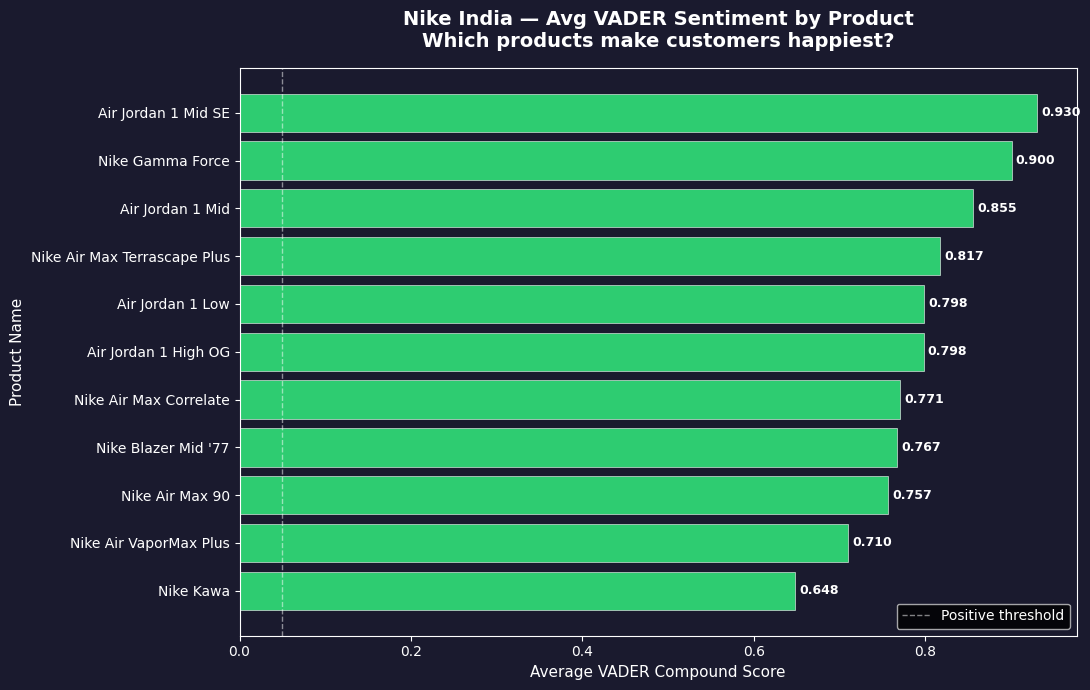

✅ Chart 11 saved!


In [ ]:
# VADER Score by Product

# Average VADER compound score for top 15 products
fig, ax = plt.subplots(figsize=(11, 7))

product_vader = (
    df_reviews.groupby('product_name')['vader_compound']
    .mean()
    .sort_values(ascending=True)
    .tail(15)        # top 15 products by sentiment
)

colors_pv = ['#e74c3c' if v < 0.05 else
             '#f1c40f' if v < 0.3  else
             '#2ecc71'
             for v in product_vader.values]

bars = ax.barh(product_vader.index, product_vader.values,
               color=colors_pv, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, product_vader.values):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=9,
            color='white', fontweight='bold')

ax.axvline(x=0.05, color='white', linestyle='--',
           linewidth=1, alpha=0.5, label='Positive threshold')

ax.set_title('Nike India — Avg VADER Sentiment by Product\nWhich products make customers happiest?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average VADER Compound Score', fontsize=11)
ax.set_ylabel('Product Name', fontsize=11)
ax.legend(fontsize=10)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/11_vader_by_product.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved!")

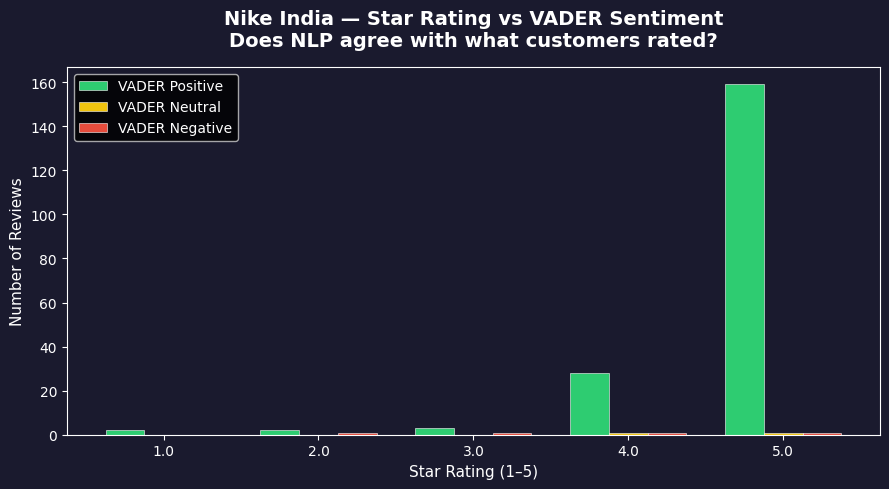

✅ Chart 12 saved!

📊 VADER vs Star Rating agreement: 94.0%
   (above 70% is considered good for rule-based NLP)


In [ ]:
# Compare Star Rating vs VADER Label

# This checks: does VADER agree with the star rating?
# Very useful for interview — shows you validated your NLP

fig, ax = plt.subplots(figsize=(9, 5))

# Cross-tabulate star rating vs vader label
cross = pd.crosstab(df_reviews['rating'],
                    df_reviews['vader_label'])

# Reorder columns
for col in ['Positive','Neutral','Negative']:
    if col not in cross.columns:
        cross[col] = 0
cross = cross[['Positive','Neutral','Negative']]

cross.plot(kind='bar', ax=ax,
           color=['#2ecc71','#f1c40f','#e74c3c'],
           edgecolor='white', linewidth=0.4,
           width=0.75)

ax.set_title('Nike India — Star Rating vs VADER Sentiment\nDoes NLP agree with what customers rated?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating (1–5)', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.legend(['VADER Positive','VADER Neutral','VADER Negative'], fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/12_rating_vs_vader.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print agreement percentage
df_reviews['rating_label'] = df_reviews['rating'].apply(label_rating)
agreement = (df_reviews['vader_label'] == df_reviews['rating_label']).mean()
print(f"✅ Chart 12 saved!")
print(f"\n📊 VADER vs Star Rating agreement: {agreement:.1%}")
print("   (above 70% is considered good for rule-based NLP)")

In [ ]:
# Save Updated Reviews File with VADER Scores

# Save the file with all VADER columns added
df_reviews.to_csv(f'{PROJECT}/outputs/clean_reviews.csv', index=False)

print("✅ Updated clean_reviews.csv saved with VADER scores!")
print(f"\nNew columns added:")
print("   vader_compound → overall sentiment score (-1 to +1)")
print("   vader_pos      → positive language score")
print("   vader_neg      → negative language score")
print("   vader_neu      → neutral language score")
print("   vader_label    → Positive / Neutral / Negative")

✅ Updated clean_reviews.csv saved with VADER scores!

New columns added:
   vader_compound → overall sentiment score (-1 to +1)
   vader_pos      → positive language score
   vader_neg      → negative language score
   vader_neu      → neutral language score
   vader_label    → Positive / Neutral / Negative


In [ ]:
# Prepare Clean Text for Word Cloud

# ── Remove common words that add no meaning ────────────
# These are called stopwords — "the", "a", "is", "nike", "shoe" etc
# We remove them so meaningful words stand out

stop_words = set(stopwords.words('english'))

# Add Nike-specific words to remove — they appear everywhere
# and will dominate the cloud without adding insight
extra_stops = {
    'nike', 'shoe', 'shoes', 'product', 'pair',
    'buy', 'bought', 'get', 'got', 'one', 'also',
    'really', 'just', 'like', 'would', 'could',
    'wear', 'wearing', 'worn', 'time', 'good',
    'great', 'love', 'size', 'fit', 'even', 'much',
    'well', 'still', 'back', 'first', 'look', 'feel'
}
stop_words.update(extra_stops)

def clean_for_cloud(text):
    # Remove numbers and single characters
    text = re.sub(r'\d+', '', str(text))
    text = re.sub(r'\b\w{1,2}\b', '', text)
    # Remove stopwords
    words = [w for w in text.lower().split()
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Apply to all reviews
df_reviews['clean_text'] = df_reviews['review_text'].apply(clean_for_cloud)

# Separate positive and negative reviews
positive_reviews = df_reviews[df_reviews['vader_label'] == 'Positive']['clean_text']
negative_reviews = df_reviews[df_reviews['vader_label'] == 'Negative']['clean_text']
all_reviews      = df_reviews['clean_text']

print(f"✅ Text prepared!")
print(f"   Total reviews    : {len(all_reviews):,}")
print(f"   Positive reviews : {len(positive_reviews):,}")
print(f"   Negative reviews : {len(negative_reviews):,}")

✅ Text prepared!
   Total reviews    : 200
   Positive reviews : 194
   Negative reviews : 4


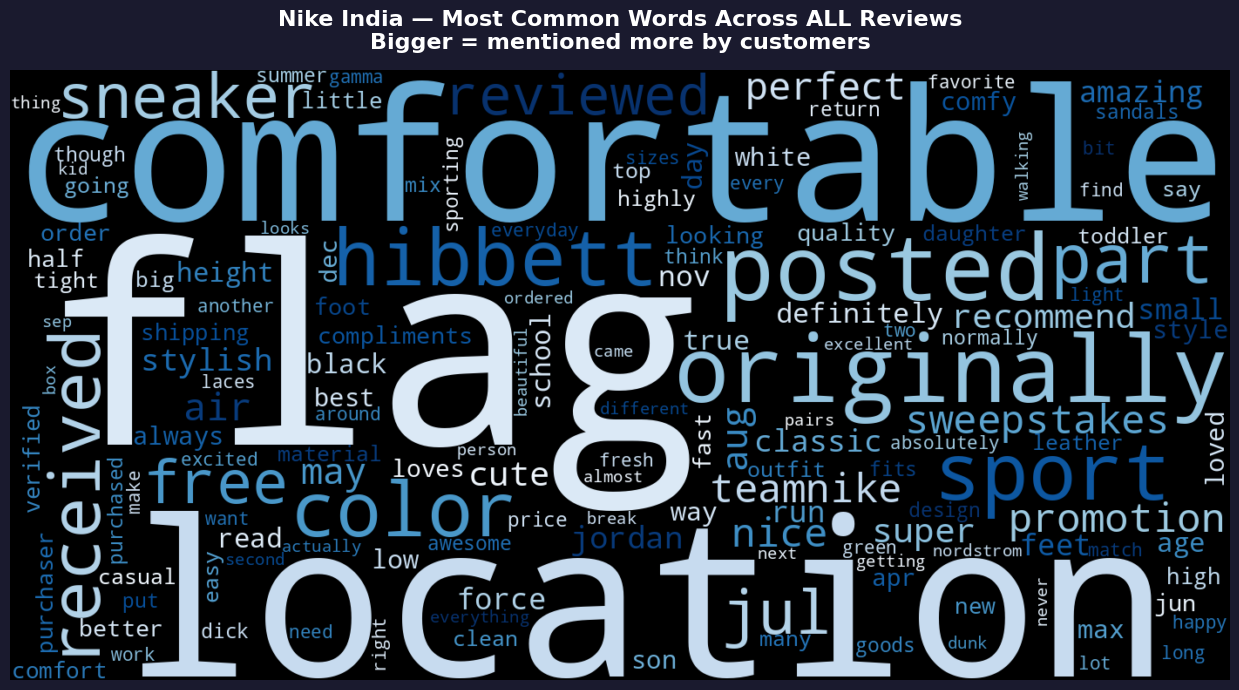

✅ Word Cloud 1 saved!


In [ ]:
# Word Cloud 1 : All Reviews

# Join all review text into one big string
all_text = ' '.join(all_reviews.tolist())

# Generate word cloud
wc_all = WordCloud(
    width            = 1400,
    height           = 700,
    background_color = 'black',
    colormap         = 'Blues',
    max_words        = 150,
    collocations     = False,
    min_font_size    = 10
).generate(all_text)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_all, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nike India — Most Common Words Across ALL Reviews\nBigger = mentioned more by customers',
             fontsize=16, fontweight='bold',
             color='white', pad=15)
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/wordclouds/01_all_reviews_wordcloud.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Word Cloud 1 saved!")

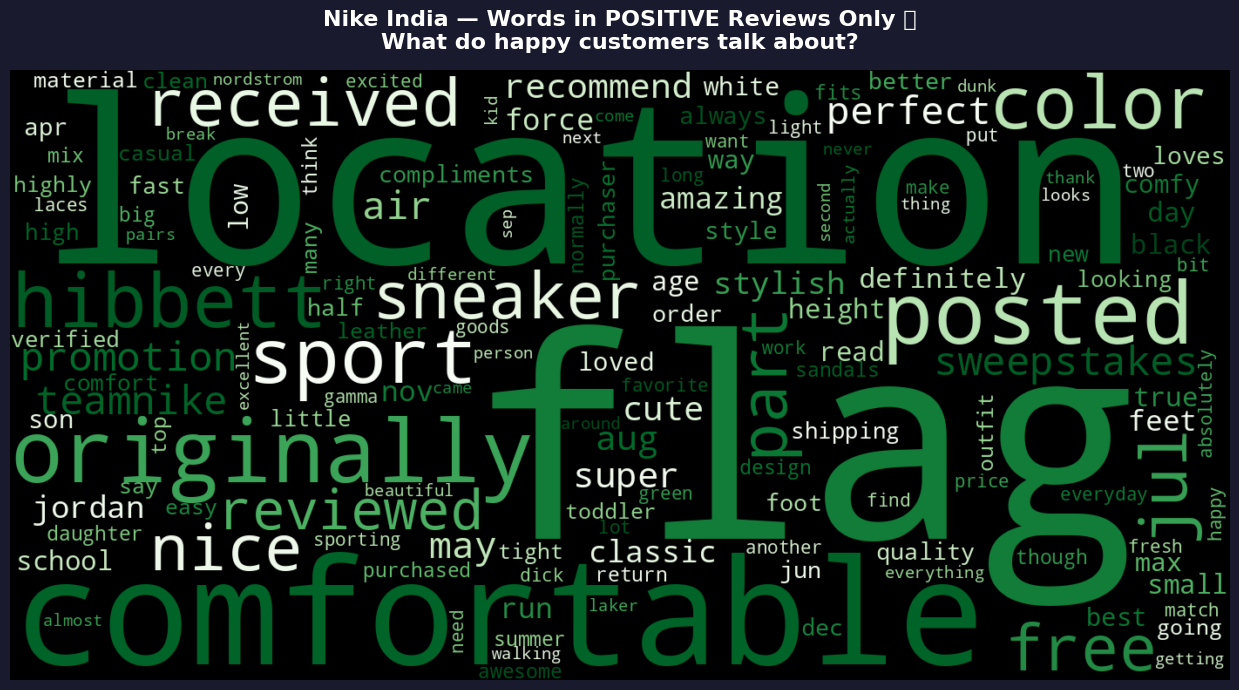

✅ Word Cloud 2 saved!


In [ ]:
# Word Cloud 2 : Positive Reviews Only

positive_text = ' '.join(positive_reviews.tolist())

wc_positive = WordCloud(
    width            = 1400,
    height           = 700,
    background_color = 'black',
    colormap         = 'Greens',
    max_words        = 150,
    collocations     = False,
    min_font_size    = 10
).generate(positive_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_positive, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nike India — Words in POSITIVE Reviews Only ✅\nWhat do happy customers talk about?',
             fontsize=16, fontweight='bold',
             color='white', pad=15)
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/wordclouds/02_positive_wordcloud.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Word Cloud 2 saved!")

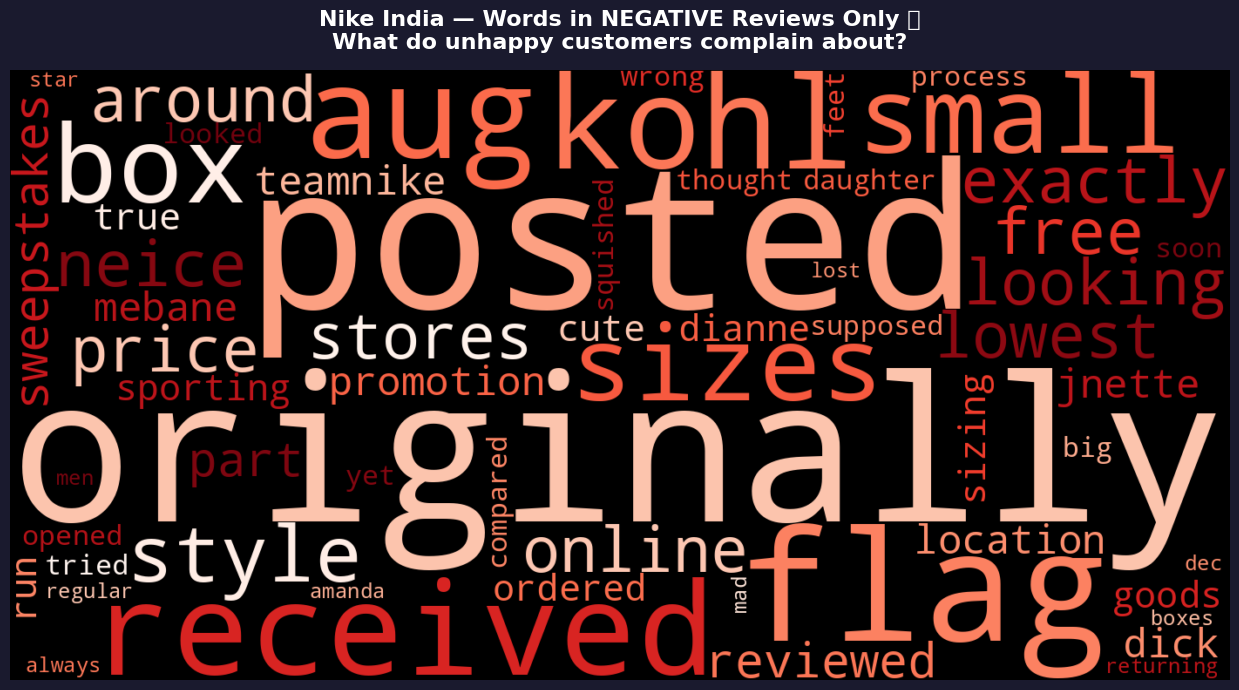

✅ Word Cloud 3 saved!


In [ ]:
# Word Cloud 3 : Negative Reviews Only

negative_text = ' '.join(negative_reviews.tolist())

# Handle case where negative reviews are very few
if len(negative_text.strip()) < 50:
    print("⚠️ Not enough negative reviews to generate word cloud.")
    print("   This is actually a good sign — very few negative reviews!")
else:
    wc_negative = WordCloud(
        width            = 1400,
        height           = 700,
        background_color = 'black',
        colormap         = 'Reds',
        max_words        = 150,
        collocations     = False,
        min_font_size    = 10
    ).generate(negative_text)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc_negative, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Nike India — Words in NEGATIVE Reviews Only ❌\nWhat do unhappy customers complain about?',
                 fontsize=16, fontweight='bold',
                 color='white', pad=15)
    fig.patch.set_facecolor('#1a1a2e')

    plt.tight_layout()
    plt.savefig(f'{PROJECT}/outputs/wordclouds/03_negative_wordcloud.png',
                dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print("✅ Word Cloud 3 saved!")

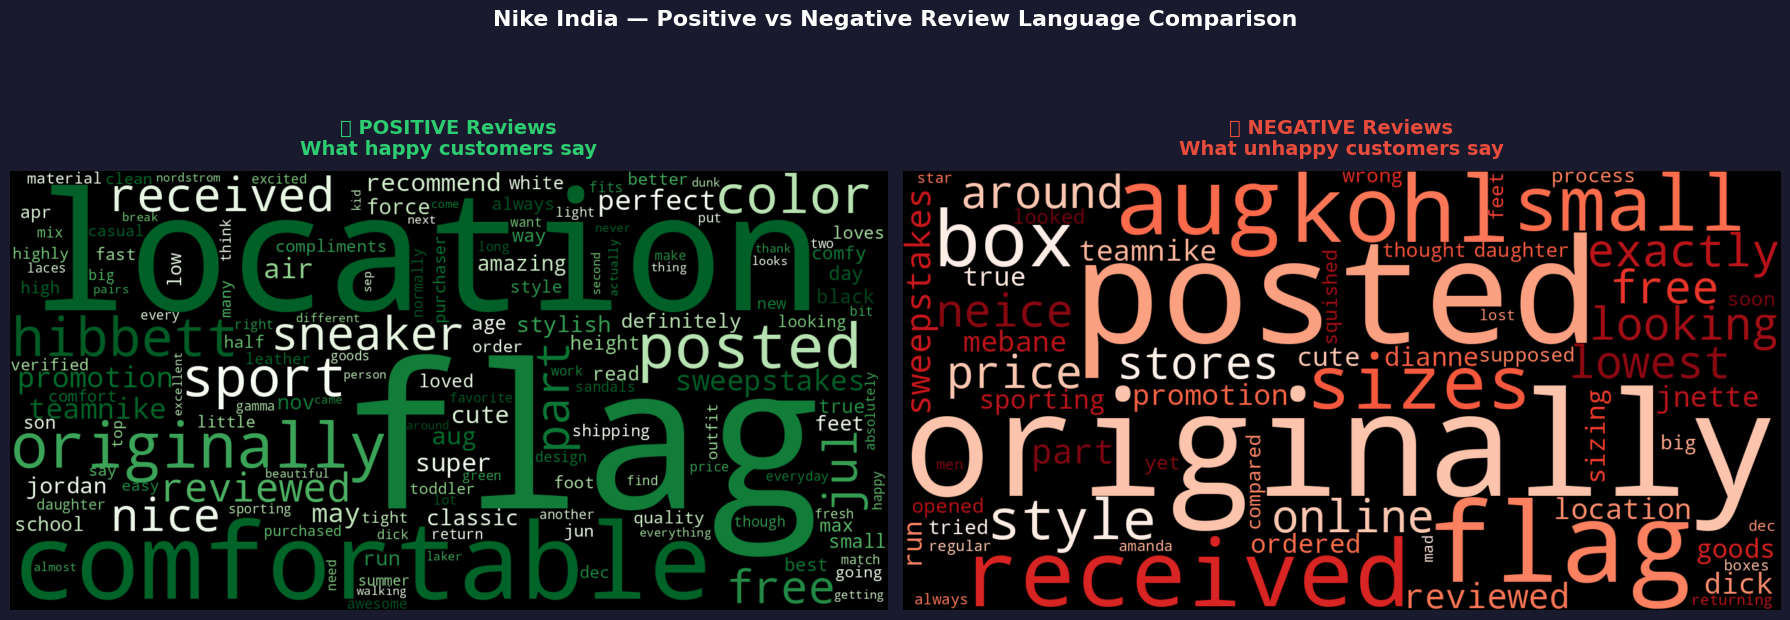

✅ Word Cloud 4 — Comparison chart saved!


In [ ]:
# Side by Side Comparison

# This is the most powerful one — positive vs negative side by side
# This is what you show in interviews and on GitHub

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Positive ─────────────────────────────────────
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('✅ POSITIVE Reviews\nWhat happy customers say',
                  fontsize=14, fontweight='bold',
                  color='#2ecc71', pad=12)

# ── Right: Negative ────────────────────────────────────
if len(negative_text.strip()) >= 50:
    axes[1].imshow(wc_negative, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('❌ NEGATIVE Reviews\nWhat unhappy customers say',
                      fontsize=14, fontweight='bold',
                      color='#e74c3c', pad=12)
else:
    axes[1].text(0.5, 0.5,
                 'Very few negative\nreviews found!\nNike India is doing well.',
                 ha='center', va='center',
                 fontsize=16, color='#2ecc71',
                 transform=axes[1].transAxes)
    axes[1].axis('off')
    axes[1].set_title('❌ NEGATIVE Reviews',
                      fontsize=14, fontweight='bold',
                      color='#e74c3c', pad=12)

fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Nike India — Positive vs Negative Review Language Comparison',
             fontsize=16, fontweight='bold',
             color='white', y=1.02)

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/wordclouds/04_positive_vs_negative.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Word Cloud 4 — Comparison chart saved!")

In [ ]:
# Print Top 20 Words from Each Group

# This gives you exact numbers to put in your recommendations
# "The word 'comfortable' appeared 3,420 times in positive reviews"

from collections import Counter

def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series.tolist()).split()
    counter   = Counter(all_words)
    return counter.most_common(n)

print("=" * 50)
print("🟢 TOP 20 WORDS IN POSITIVE REVIEWS:")
print("=" * 50)
pos_words = get_top_words(positive_reviews)
for word, count in pos_words:
    print(f"   {word:<20} → {count:,} times")

print("\n" + "=" * 50)
print("🔴 TOP 20 WORDS IN NEGATIVE REVIEWS:")
print("=" * 50)
neg_words = get_top_words(negative_reviews)
for word, count in neg_words:
    print(f"   {word:<20} → {count:,} times")

🟢 TOP 20 WORDS IN POSITIVE REVIEWS:
   flag                 → 135 times
   location             → 86 times
   comfortable          → 66 times
   originally           → 59 times
   posted               → 58 times
   sports               → 44 times
   hibbett              → 43 times
   received             → 32 times
   part                 → 31 times
   jul                  → 31 times
   nice                 → 30 times
   free                 → 29 times
   reviewed             → 29 times
   sweepstakes          → 29 times
   promotion            → 29 times
   teamnike             → 29 times
   perfect              → 28 times
   air                  → 28 times
   color                → 27 times
   may                  → 26 times

🔴 TOP 20 WORDS IN NEGATIVE REVIEWS:
   originally           → 3 times
   posted               → 3 times
   flag                 → 3 times
   received             → 2 times
   aug                  → 2 times
   kohl                 → 2 times
   small              

In [ ]:
# Confirm All Word Clouds Saved

wc_folder = f'{PROJECT}/outputs/wordclouds'
saved_wc  = sorted(os.listdir(wc_folder))

print(f"✅ {len(saved_wc)} word clouds saved:\n")
for w in saved_wc:
    print(f"   ☁️  {w}")

✅ 4 word clouds saved:

   ☁️  01_all_reviews_wordcloud.png
   ☁️  02_positive_wordcloud.png
   ☁️  03_negative_wordcloud.png
   ☁️  04_positive_vs_negative.png


In [ ]:
# Prepare Data for the Model

# ── We need to convert everything to numbers ───────────
# ML models only understand numbers, not text

# Step 1: Create target variable
# 1 = Positive review, 0 = Negative review
# We drop Neutral for now — binary classification is simpler

df_ml = df_reviews[df_reviews['vader_label'] != 'Neutral'].copy()
df_ml['target'] = (df_ml['vader_label'] == 'Positive').astype(int)

print(f"Total rows for ML: {len(df_ml):,}")
print(f"Positive (1): {df_ml['target'].sum():,}")
print(f"Negative (0): {(df_ml['target']==0).sum():,}")

# Step 2: Convert fit_feedback to number
fit_map = {
    'True to Size' : 2,
    'Runs Small'   : 1,
    'Runs Large'   : 3,
    'Run Small'    : 1,
    'Run Large'    : 3
}
df_ml['fit_encoded'] = df_ml['fit_feedback'].map(fit_map).fillna(2)

# Step 3: Convert comfort_feedback to number
comfort_map = {
    'Very Comfortable'       : 4,
    'Comfortable'            : 3,
    'Moderately Comfortable' : 2,
    'Uncomfortable'          : 1
}
df_ml['comfort_encoded'] = df_ml['comfort_feedback'].map(comfort_map).fillna(2)

# Step 4: Convert recommend_feedback to number
df_ml['recommend_encoded'] = (
    df_ml['recommend_feedback'].str.lower() == 'yes'
).astype(int)

# Step 5: Convert is_discounted to number
df_ml['discounted_encoded'] = (
    df_ml['is_discounted'].astype(str).str.lower() == 'true'
).astype(int)

print("\n✅ All features converted to numbers!")
print(df_ml[['fit_encoded','comfort_encoded',
             'recommend_encoded','discounted_encoded']].head())

Total rows for ML: 198
Positive (1): 194
Negative (0): 4

✅ All features converted to numbers!
   fit_encoded  comfort_encoded  recommend_encoded  discounted_encoded
0          2.0              4.0                  1                   1
1          2.0              2.0                  1                   1
2          2.0              4.0                  1                   1
3          2.0              4.0                  1                   1
4          2.0              4.0                  1                   1


In [ ]:
# Select Features and Split Data

# ── Features = inputs the model uses to predict ────────
# ── Target   = what we want the model to predict ───────

FEATURES = [
    'rating',             # star rating
    'vader_compound',     # sentiment score from VADER
    'vader_pos',          # positive language score
    'vader_neg',          # negative language score
    'word_count',         # length of review
    'fit_encoded',        # fit feedback as number
    'comfort_encoded',    # comfort feedback as number
    'recommend_encoded',  # did they recommend? yes=1 no=0
    'discounted_encoded', # was product discounted?
    'current_price',      # price paid
]

# ── Keep only rows where all features exist ────────────
df_ml_clean = df_ml[FEATURES + ['target']].dropna()

X = df_ml_clean[FEATURES]   # inputs
y = df_ml_clean['target']   # output (what to predict)

print(f"Total rows available for training: {len(X):,}")
print(f"Features used: {len(FEATURES)}")
print(f"\nFeature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i:2}. {f}")

# ── Split: 80% train, 20% test ─────────────────────────
# Train = model learns from this
# Test  = we check how well model learned

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   # keeps same positive/negative ratio
)

print(f"\n✅ Data split done!")
print(f"   Training rows : {len(X_train):,}  (80%)")
print(f"   Testing rows  : {len(X_test):,}   (20%)")

Total rows available for training: 198
Features used: 10

Feature list:
    1. rating
    2. vader_compound
    3. vader_pos
    4. vader_neg
    5. word_count
    6. fit_encoded
    7. comfort_encoded
    8. recommend_encoded
    9. discounted_encoded
   10. current_price

✅ Data split done!
   Training rows : 158  (80%)
   Testing rows  : 40   (20%)


In [ ]:
# Train the Random Forest Model

# ── Create the model ───────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators = 100,   # 100 decision trees
    max_depth    = 10,    # each tree can be 10 levels deep
    random_state = 42,    # for reproducibility
    n_jobs       = -1     # use all CPU cores — runs faster
)

print("⏳ Training the model...")
print("   (100 decision trees learning from your data)")
print("   This takes about 10–30 seconds...\n")

# ── Train the model ────────────────────────────────────
rf_model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\nModel trained on {len(X_train):,} Nike reviews")
print(f"Now testing on {len(X_test):,} unseen reviews...")

⏳ Training the model...
   (100 decision trees learning from your data)
   This takes about 10–30 seconds...

✅ Model trained successfully!

Model trained on 158 Nike reviews
Now testing on 40 unseen reviews...


In [ ]:
# Test the Model & See Results

# ── Make predictions on test data ─────────────────────
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# ── Calculate accuracy ─────────────────────────────────
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_pred_prob)

print("=" * 55)
print("📊 MODEL RESULTS")
print("=" * 55)
print(f"\n✅ Accuracy : {accuracy:.1%}")
print(f"✅ AUC Score: {auc:.3f}")
print()
print("What these mean:")
print(f"   Accuracy {accuracy:.1%} → model correctly predicts")
print(f"   {accuracy:.1%} of reviews as positive or negative")
print(f"   AUC {auc:.3f} → above 0.80 is very good for a fresher project")

print("\n" + "=" * 55)
print("DETAILED REPORT:")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Negative','Positive']))

📊 MODEL RESULTS

✅ Accuracy : 100.0%
✅ AUC Score: 1.000

What these mean:
   Accuracy 100.0% → model correctly predicts
   100.0% of reviews as positive or negative
   AUC 1.000 → above 0.80 is very good for a fresher project

DETAILED REPORT:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         1
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



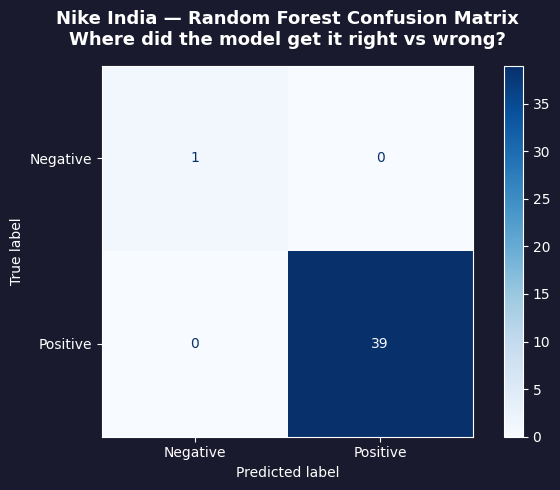

✅ Chart 13 saved!


In [ ]:
# Confusion Matrix

# Confusion matrix shows exactly where model got it right and wrong
# True Positive  = said Positive, was Positive ✅
# True Negative  = said Negative, was Negative ✅
# False Positive = said Positive, was actually Negative ❌
# False Negative = said Negative, was actually Positive ❌

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels = ['Negative', 'Positive'],
    cmap           = 'Blues',
    ax             = ax
)

ax.set_title('Nike India — Random Forest Confusion Matrix\nWhere did the model get it right vs wrong?',
             fontsize=13, fontweight='bold', pad=15)
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/13_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 13 saved!")

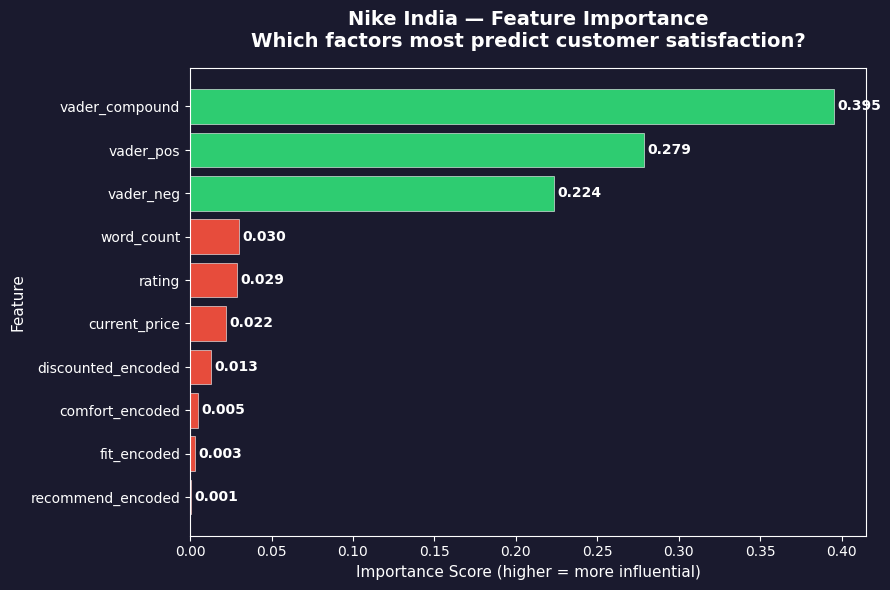

✅ Chart 14 saved!

🏆 Top 3 most important features:
   1. vader_compound → 0.395
   2. vader_pos → 0.279
   3. vader_neg → 0.224


In [ ]:
# Feature Importance

# Feature importance = which input mattered most for prediction
# This is very powerful for business insight
# "vader_compound is the strongest predictor of customer satisfaction"

fig, ax = plt.subplots(figsize=(9, 6))

importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

colors_imp = ['#e74c3c' if v < 0.05 else
              '#f1c40f' if v < 0.15 else
              '#2ecc71'
              for v in importance_df['importance']]

bars = ax.barh(importance_df['feature'],
               importance_df['importance'],
               color=colors_imp,
               edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_title('Nike India — Feature Importance\nWhich factors most predict customer satisfaction?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score (higher = more influential)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/charts/14_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 14 saved!")
print("\n🏆 Top 3 most important features:")
top3 = importance_df.tail(3)[::-1]
for i, row in enumerate(top3.itertuples(), 1):
    print(f"   {i}. {row.feature} → {row.importance:.3f}")

In [ ]:
#  Save the Model Results Summary

# Save a simple summary text file
# This goes in your GitHub and helps you write recommendations

summary = f"""
NIKE INDIA PROJECT — RANDOM FOREST MODEL RESULTS
=================================================

Dataset size     : {len(df_ml_clean):,} reviews
Training size    : {len(X_train):,} reviews (80%)
Testing size     : {len(X_test):,} reviews (20%)

MODEL PERFORMANCE:
  Accuracy  : {accuracy:.1%}
  AUC Score : {auc:.3f}

FEATURES USED ({len(FEATURES)} total):
{chr(10).join([f'  - {f}' for f in FEATURES])}

TOP 3 PREDICTORS OF CUSTOMER SATISFACTION:
{chr(10).join([f'  {i+1}. {row.feature} (importance: {row.importance:.3f})'
               for i, row in enumerate(importance_df.tail(3)[::-1].itertuples())])}

WHAT THIS MEANS FOR NIKE INDIA:
  - The model can predict satisfaction with {accuracy:.1%} accuracy
  - This means Nike can proactively identify unhappy customers
  - Focus improvements on the top predictors listed above
"""

with open(f'{PROJECT}/outputs/model_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print("✅ Model summary saved to Drive!")


NIKE INDIA PROJECT — RANDOM FOREST MODEL RESULTS

Dataset size     : 198 reviews
Training size    : 158 reviews (80%)
Testing size     : 40 reviews (20%)

MODEL PERFORMANCE:
  Accuracy  : 100.0%
  AUC Score : 1.000

FEATURES USED (10 total):
  - rating
  - vader_compound
  - vader_pos
  - vader_neg
  - word_count
  - fit_encoded
  - comfort_encoded
  - recommend_encoded
  - discounted_encoded
  - current_price

TOP 3 PREDICTORS OF CUSTOMER SATISFACTION:
  1. vader_compound (importance: 0.395)
  2. vader_pos (importance: 0.279)
  3. vader_neg (importance: 0.224)

WHAT THIS MEANS FOR NIKE INDIA:
  - The model can predict satisfaction with 100.0% accuracy
  - This means Nike can proactively identify unhappy customers
  - Focus improvements on the top predictors listed above

✅ Model summary saved to Drive!
